# ADL benchmarks on **graphed** — interactive exploration

The eight [IRIS-HEP ADL functionality benchmarks](https://github.com/iris-hep/adl-benchmarks-index)
on **coffea NanoEvents in graphed mode**, mirroring this repository's original
`coffea-adl-benchmarks.ipynb`. `NanoEventsFactory.from_root(..., mode="graphed")` gives the same
`events.Muon`, `events.Jet` and behaviors you know, but deferred: each query records a graph,
fills a deferred `hist.graphed` histogram, and a **process pool** runs it partition by partition.
Nothing below materializes the dataset; each partition reads only the branches its query touches.

Data: a committed 50k-event skim of `Run2012B_SingleMu.root` (`data/Run2012B_SingleMu_50k.root`).
The acceptance tests pin every histogram **bit for bit** against the original coffea processors
(sequential tier; the parallel tier agrees to rounding).

In [1]:
import inspect
import time

import matplotlib.pyplot as plt
import uproot
from graphed_executors.local import ProcessPoolExecutor

import adl_graphed as adl

WHERE = "data/Run2012B_SingleMu_50k.root"
# ONE persistent pool for the whole notebook: the import-heavy worker spawn is paid once and
# amortized over every query below (close()d at the end)
EXECUTOR = ProcessPoolExecutor(max_workers=4, persistent=True)
# NanoEventsFactory.from_root({WHERE: "Events"}, schemaclass=NanoAODSchema, mode="graphed").events()
events = adl.events(WHERE)
events

Array(node_id=0)

## Exploring the deferred array

`events` is a lazy NanoEvents record. Operations **record** instead of executing; forms are
inferred by awkward's typetracer, and the buffer projection reports exactly what a result would
read. The plan reads the branches behind those buffers, plus the collection's counter (`nMuon`)
that NanoAOD stores the jagged structure in.

In [2]:
from graphed.awkward import gak, project_buffers


def needs(x):
    return {k: v.value for k, v in project_buffers(x).read_buffers["Events"].items()}


print("form:", events.session.form(events.Muon).describe()[:90])
print("pt of a four-vector property needs:", needs(events.Muon.pt))
print("but .px (a DERIVED property) needs:", needs(events.Muon.px))

form: ## * var * Muon[pt: float32[parameters={"__doc__": "Muon_pt[nMuon]/F", "typename": "float[
pt of a four-vector property needs: {'Muon.pt': 'data'}
but .px (a DERIVED property) needs: {'Muon.pt': 'data', 'Muon.phi': 'data'}


In [3]:
# peek at the first events WITHOUT reading the rest of the file
import awkward as ak

ak.Array(uproot.graphed_head(events.Muon.pt, 5)).tolist()

[[12.77709674835205],
 [24.76300621032715],
 [37.74860382080078,
  6.9919257164001465,
  3.349816083908081,
  7.9132561683654785,
  5.379203796386719,
  9.373967170715332],
 [30.48163414001465],
 [33.53227615356445]]

In [4]:
# the compiled IR is a handful of fused stages, not one node per recorded op
import graphed.core
from graphed import compile_ir

expr = events.Muon.pt > 30.0
nodes = graphed.core.GraphStore.deserialize(compile_ir(events.session, expr).ir).nodes()
[(n["kind"], n.get("n_members", "")) for n in nodes]

[('source', ''), ('stage', 3)]

## The eight queries — aggregated by the process pool

Each query is the original coffea processor's body in the deferred spelling, as with dask:
`gak` for `ak` and `hist.graphed` for `hist`. Every plot below is produced by **4 parallel
workers** (`EXECUTOR`): each query's plan is a task graph of per-partition fills, tree-reduced by
histogram addition.

### **Q1** — Plot the missing transverse energy of all events.

In [5]:
print(inspect.getsource(adl.QUERIES["q1"]))

def q1(events):
    """MET of all events."""
    return hg.Hist.new.Reg(100, 0, 200, name="met", label="$E_{T}^{miss}$ [GeV]").Double().fill(events.MET.pt)



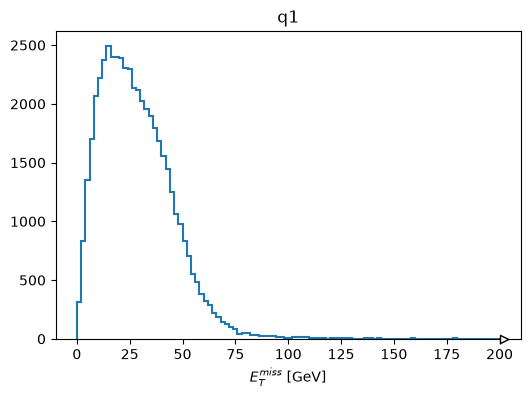

In [6]:
out = adl.run_query("q1", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q2** — Plot the $p_T$ of all jets (ragged fills flatten).

In [7]:
print(inspect.getsource(adl.QUERIES["q2"]))

def q2(events):
    """pT of all jets."""
    return (
        hg.Hist.new.Reg(100, 0, 200, name="ptj", label="Jet $p_{T}$ [GeV]")
        .Double()
        .fill(gak.flatten(events.Jet.pt))
    )



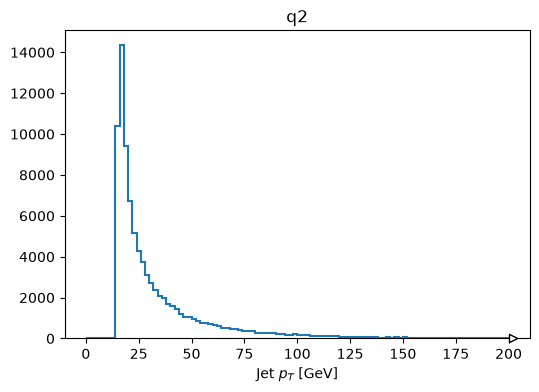

In [8]:
out = adl.run_query("q2", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q3** — Plot the $p_T$ of jets with $|\eta| < 1$.

In [9]:
print(inspect.getsource(adl.QUERIES["q3"]))

def q3(events):
    """pT of jets with |eta| < 1."""
    return (
        hg.Hist.new.Reg(100, 0, 200, name="ptj", label="Jet $p_{T}$ [GeV]")
        .Double()
        .fill(gak.flatten(events.Jet[abs(events.Jet.eta) < 1].pt))
    )



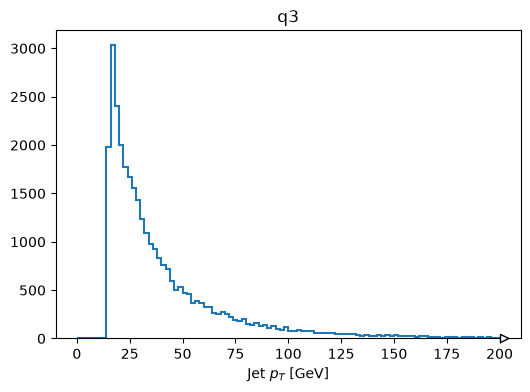

In [10]:
out = adl.run_query("q3", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q4** — Plot the MET of events with at least two jets above 40 GeV.

In [11]:
print(inspect.getsource(adl.QUERIES["q4"]))

def q4(events):
    """MET of events with at least two jets above 40 GeV."""
    has2jets = gak.sum(events.Jet.pt > 40, axis=1) >= 2
    return (
        hg.Hist.new.Reg(100, 0, 200, name="met", label="$E_{T}^{miss}$ [GeV]")
        .Double()
        .fill(events[has2jets].MET.pt)
    )



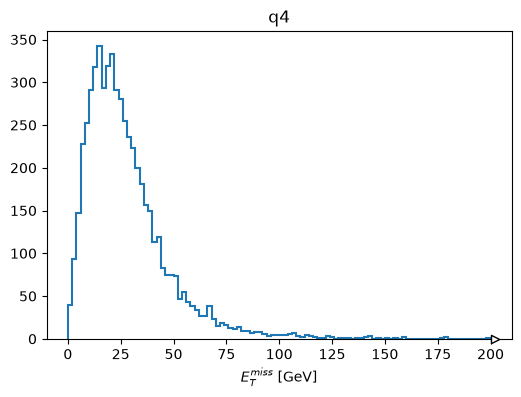

In [12]:
out = adl.run_query("q4", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q5** — Plot the MET of events with an opposite-charge dimuon pair with mass 60–120 GeV.

In [13]:
print(inspect.getsource(adl.QUERIES["q5"]))

def q5(events):
    """MET of events with an opposite-charge dimuon pair of mass 60-120 GeV."""
    mupair = gak.combinations(events.Muon, 2, fields=["mu1", "mu2"])
    pairmass = (mupair.mu1 + mupair.mu2).mass
    goodevent = gak.any(
        (pairmass > 60) & (pairmass < 120) & (mupair.mu1.charge == -mupair.mu2.charge),
        axis=1,
    )
    return (
        hg.Hist.new.Reg(100, 0, 200, name="met", label="$E_{T}^{miss}$ [GeV]")
        .Double()
        .fill(events[goodevent].MET.pt)
    )



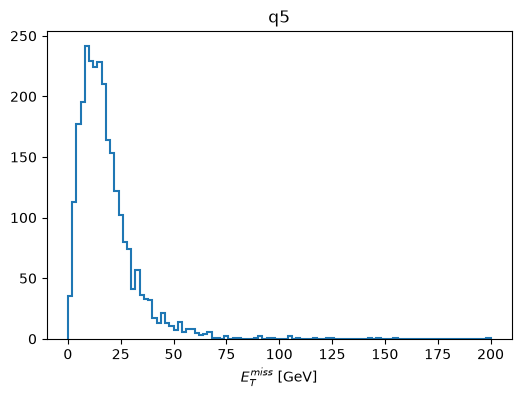

In [14]:
out = adl.run_query("q5", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q6** — For events with ≥3 jets: the $p_T$ of the trijet closest to the top mass, and its maximum b-tag.

In [15]:
print(inspect.getsource(adl.QUERIES["q6"]))

def q6(events):
    """pT of the trijet closest to the top mass, and the maximum b-tag among its jets."""
    jets = gak.zip(
        {k: getattr(events.Jet, k) for k in ["x", "y", "z", "t", "btag"]},
        with_name="LorentzVector",
    )
    trijet = gak.combinations(jets, 3, fields=["j1", "j2", "j3"])
    trijet = gak.with_field(trijet, trijet.j1 + trijet.j2 + trijet.j3, "p4")
    trijet = gak.flatten(trijet[gak.singletons(gak.argmin(abs(trijet.p4.mass - 172.5), axis=1))])
    max_btag = np.maximum(trijet.j1.btag, np.maximum(trijet.j2.btag, trijet.j3.btag))
    return {
        "trijetpt": hg.Hist.new.Reg(100, 0, 200, name="pt3j", label="Trijet $p_{T}$ [GeV]")
        .Double()
        .fill(trijet.p4.pt),
        "maxbtag": hg.Hist.new.Reg(100, 0, 1, name="btag", label="Max jet b-tag score")
        .Double()
        .fill(max_btag),
    }



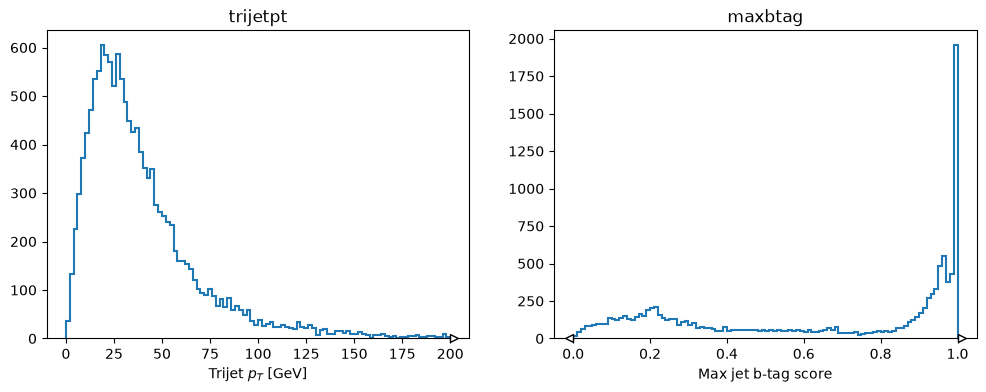

In [16]:
out = adl.run_query("q6", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q7** — Scalar sum of jet $p_T$ (jets > 30 GeV not within ΔR 0.4 of any lepton > 10 GeV).

In [17]:
print(inspect.getsource(adl.QUERIES["q7"]))

def q7(events):
    """Scalar sum of the pT of jets above 30 GeV not within dR 0.4 of a lepton above 10 GeV."""
    cleanjets = events.Jet[
        gak.all(events.Jet.metric_table(events.Muon[events.Muon.pt > 10]) >= 0.4, axis=2)
        & gak.all(events.Jet.metric_table(events.Electron[events.Electron.pt > 10]) >= 0.4, axis=2)
        & (events.Jet.pt > 30)
    ]
    return (
        hg.Hist.new.Reg(100, 0, 200, name="sumjetpt", label=r"Jet $\sum p_{T}$ [GeV]")
        .Double()
        .fill(gak.sum(cleanjets.pt, axis=1))
    )



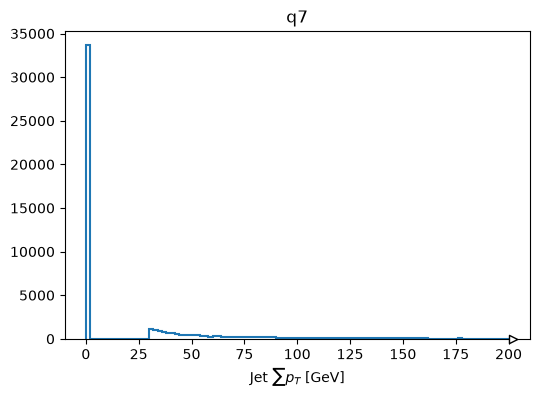

In [18]:
out = adl.run_query("q7", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### **Q8** — Transverse mass of MET + the leading light lepton outside the best same-flavor opposite-charge pair.

In [19]:
print(inspect.getsource(adl.QUERIES["q8"]))

def q8(events):
    """Transverse mass of MET and the leading lepton outside the SFOS pair closest to the Z."""

    # Leptons as one record type (concatenating Electron with Muon makes a union, which is slow
    # and has no delta_phi) kept beside MET: a field assigned onto `events` makes every read
    # also fetch other collections' counters.
    def lepton(collection, pdg):
        fields = {k: getattr(collection, k) for k in ["pt", "eta", "phi", "mass", "charge"]}
        return gak.zip({**fields, "pdgId": pdg * collection.charge}, with_name="PtEtaPhiMCandidate")

    leptons = gak.concatenate([lepton(events.Electron, -11), lepton(events.Muon, -13)], axis=1)
    has3 = gak.num(leptons) >= 3
    leptons, met = leptons[has3], events.MET[has3]

    pair = gak.argcombinations(leptons, 2, fields=["l1", "l2"])
    pair = pair[(leptons[pair.l1].pdgId == -leptons[pair.l2].pdgId)]
    pair = pair[gak.singletons(gak.argmin(abs((leptons[pair.l1] + leptons[pair.l2]).mass - 91.2), axis=1))]
  

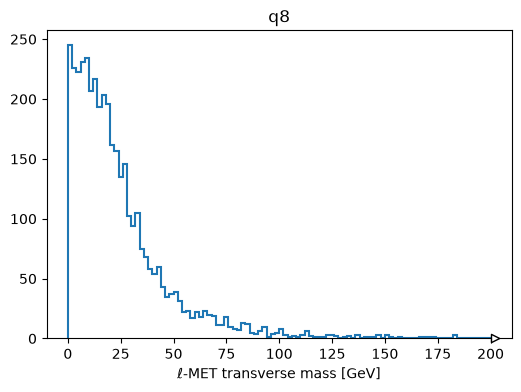

In [20]:
out = adl.run_query("q8", WHERE, steps_per_file=8, executor=EXECUTOR)
fig, axes = plt.subplots(1, len(out), figsize=(6 * len(out), 4), squeeze=False)
for ax, (label, h) in zip(axes[0], out.items()):
    h.plot1d(ax=ax)
    ax.set_title(label)
plt.show()

### Categories you don't know up front: growth axes

You rarely know every jet multiplicity, dataset name or trigger path before you look. Give an
axis `growth=True` and each partition fills whatever it sees; adding the partial histograms
merges the category lists (in order of first appearance) and widens growing `Regular` axes on
the same bin grid to their union. Below, the number of jets above 40 GeV is a growing integer
category and MET starts at 0–100 GeV and grows; eight partitions run on the pool, and the result
is compared with one eager `hist` fill of the whole file.

In [21]:
import awkward as ak
import graphed_histogram as gh
import hist
import hist.graphed as hg

njet = gak.num(events.Jet[events.Jet.pt > 40.0], axis=1)
h_growth = (
    hg.Hist.new.IntCat([], name="njet", growth=True)
    .Reg(10, 0, 100, name="met", growth=True)
    .Int64()
    .fill(njet=njet, met=events.MET.pt)
)
growth_plan = gh.plan({"h": h_growth}, steps_per_file=8)
out = hist.Hist(EXECUTOR.run(growth_plan).value["h"])
print("njet categories:", list(out.axes["njet"]))
print(
    f"MET axis grew to {out.axes['met'].size} bins, {out.axes['met'].edges[0]:.0f}-{out.axes['met'].edges[-1]:.0f} GeV"
)

raw = uproot.open(WHERE)["Events"].arrays(["Jet_pt", "MET_pt"])
nj = ak.num(raw.Jet_pt[raw.Jet_pt > 40.0], axis=1).to_numpy()
print("largest njet in each partition:", [int(nj[lo : lo + 6250].max()) for lo in range(0, len(nj), 6250)])
eager = hist.Hist.new.IntCat([], name="njet", growth=True).Reg(10, 0, 100, name="met", growth=True).Int64()
eager.fill(njet=nj, met=raw.MET_pt.to_numpy())
print("equal to one eager fill of the whole file:", out == eager)

njet categories: [1, 0, 2, 3, 4, 5, 6]
MET axis grew to 56 bins, 0-560 GeV
largest njet in each partition: [5, 6, 5, 5, 5, 6, 5, 5]
equal to one eager fill of the whole file: True


## Systematic variations — JES and b-tagging: one program, the full 15-universe grid

Real analyses fill hundreds of histograms across dozens of systematic *universes* — the many-universes picture from the neutrino *multisim* method ([MiniBooNE, Phys. Rev. D 79, 072002 (2009)](https://arxiv.org/abs/0806.1449)) and the ATLAS/CMS *bootstrap* ([ATL-PHYS-PUB-2021-011](https://cds.cern.ch/record/2759945)). Two kinds
dominate, and `graphed` expresses both through the same `graphed.vary` declaration — declared once,
then carried through the recorded program the way
[RDataFrame's `Vary`](https://root.cern/doc/master/classROOT_1_1RDF_1_1RInterface.html) does,
sharing every unvaried sub-computation and running in a single pass:

- a **kinematic** systematic — the **jet-energy scale** — shifts the jet four-vector itself, so it
  moves jets in and out of the **Q6** trijet selection *and* changes the observable. The scale is a
  real **correctionlib** set (`JES_Total.evaluate(eta, pt) → fractional δ`), recorded as an
  `External` node — not a Python lambda — so it serializes into the durable plan and reproduces
  bit-for-bit on another machine.
- a **weight** systematic — **b-tagging** — reweights each event by the correctionlib
  `deepJet_shape` per-jet scale factor, multiplied over the three jets the Q6 selection picks.

Each is **one plain `graphed.vary(...)` call** — no joint bookkeeping, no placement list. But the
b-tag scale factor is *built from the JES-varied jets*, so the b-tag family genuinely **depends on**
the jes axis, and `graphed` mints the complete **3 × 5 = 15**-universe grid on its own:

```
nominal
jes_up  jes_down                                                   # the jes axis
btag_hf_up  btag_hf_down  btag_lf_up  btag_lf_down                 # the b-tag axis  (7 so far: the datacard set)
btag_hf_up__jes_up  btag_hf_up__jes_down  …  btag_lf_down__jes_down   # + 8 joint cross-terms
```

The **8 joints** are the real **factorization cross-terms** (the non-factorizable part): each b-tag variation evaluated
at *its own* jes coordinate — `btag_hf_up__jes_up` is the hf-up scale factor computed on the jes-up jets — the actual cross node the graph already holds. Nothing in the analysis code loops over
universes or registers a cross term; the dependency is discovered from the graph, and before auto-fanout it collapsed to nominal, silently discarding the real cross-term.

### Why the cross-terms are physical, and how to collapse them back

`deepJet_shape` is binned in jet $p_T$, and `gak.apply_correction` runs on the **JES-varied** trijet
— a `Varied` container it traverses, re-evaluating the correction per universe. So the b-tag SF in
`btag_hf_up__jes_up` is computed from *that* universe's shifted $p_T$, which is what makes the joint a
distinct template rather than a copy of the one-at-a-time b-tag universe. Summed over all 50k events, Σ SF = **49625.198758** nominal → **49634.770145** in `jes_up`, and the joints displace it further still. (Most events have no trijet and contribute a trivial 1.0 apiece, so among those that do the shift is several times this fraction.)

A CMS **datacard** does not carry 2-D cross-product templates — it keeps the **7 one-at-a-time**
variations, `{nominal, jes_±, btag_hf_±, btag_lf_±}`, and the fit profiles the nuisance parameters. That prune is an **analysis choice**, applied with a single keyword —
`graphed.vary(..., composes_as_union=True)` — not the framework default. The default makes no such choice: it is the **complete grid** of universes the dependency implies, from which `composes_as_union=True`, explicit
`{nuisance: coordinate}` placements in `points=`, or a `max_universes=` budget mold whatever the
analysis actually wants.

One recorded plan over **two** Q6 observables (plus the Σ SF witness), read once through the
persistent pool, yields all fifteen universes of each; `graphed_histogram.unpack` splits the
aggregate back into `{universe: histogram}`. `gak.apply_correction` records a preservable `External`
(payload + call template + content hash), not a closure, so the whole thing pickles into the durable
plan and each pool worker rebuilds the correction set from the payload bytes — one recorded program,
one pass, every universe.

> **Selecting or bounding the grid** — a factorization study may want only the *diagonal* joints, a
> correlated μR×μF scale grid uses custom numeric coordinates, and a chain of several nuisances can
> blow the grid past a sane budget. `{nuisance: coordinate}` placements mixed into `points=` prune the auto grid to named coordinate
> maps — they are also the precision knob for non-±1σ points, and can re-point an independent member
> off-grid — and `max_universes=` is the loud guard that fires before a runaway grid is minted. The
> [`graphed.vary` tour](./graphed-vary-systematics-tour.ipynb) walks through every mode.

> The two correctionlib sets are built in `systematics.py` to stand in for the POG JSONs
> (`Summer19UL16_V7` JES, DeepJet shape) — identical structure and evaluation, no external download;
> `deepJet_shape` is $p_T$-binned, as the real one is. Because the 50k skim carries no
> `Jet_hadronFlavour`, hadron flavour is proxied from the b-tag discriminant, and the shape-method
> renormalisation is omitted; a production run reads the truth branch and renormalises. The point is
> the *interface*, not the calibration numbers.

universes: ('nominal', 'jes_up', 'jes_down', 'btag_hf_up', 'btag_hf_down', 'btag_lf_up', 'btag_lf_down', 'btag_hf_up__jes_up', 'btag_hf_up__jes_down', 'btag_hf_down__jes_up', 'btag_hf_down__jes_down', 'btag_lf_up__jes_up', 'btag_lf_up__jes_down', 'btag_lf_down__jes_up', 'btag_lf_down__jes_down')



universe         sum(trijet_pt)  sum(max_btag)    sum(b-tag SF)
nominal            13264.831233   11905.845140     49625.198758
jes_up             13260.481247   11903.093859     49634.770145
jes_down           13264.987557   11916.669489     49616.386278
btag_hf_up         13689.838720   12331.403642     50052.179259
btag_hf_down       12851.136840   11491.552806     49209.536586
btag_lf_up         15942.907797   14229.839673     52325.152667
btag_lf_down       10910.430779    9852.927246     47251.702970
btag_hf_up__jes_up   13686.555010   12330.128900     50063.230854
btag_hf_up__jes_down   13688.357614   12340.393318     50041.424798
btag_hf_down__jes_up   12845.706655   11487.316217     49217.619004
btag_hf_down__jes_down   12852.758236   11504.044767     49202.493749
btag_lf_up__jes_up   15935.406674   14223.598779     52334.427944
btag_lf_up__jes_down   15945.760300   14246.511181     52317.275445
btag_lf_down__jes_up   10908.482350    9852.781899     47261.158100
btag_lf_down_

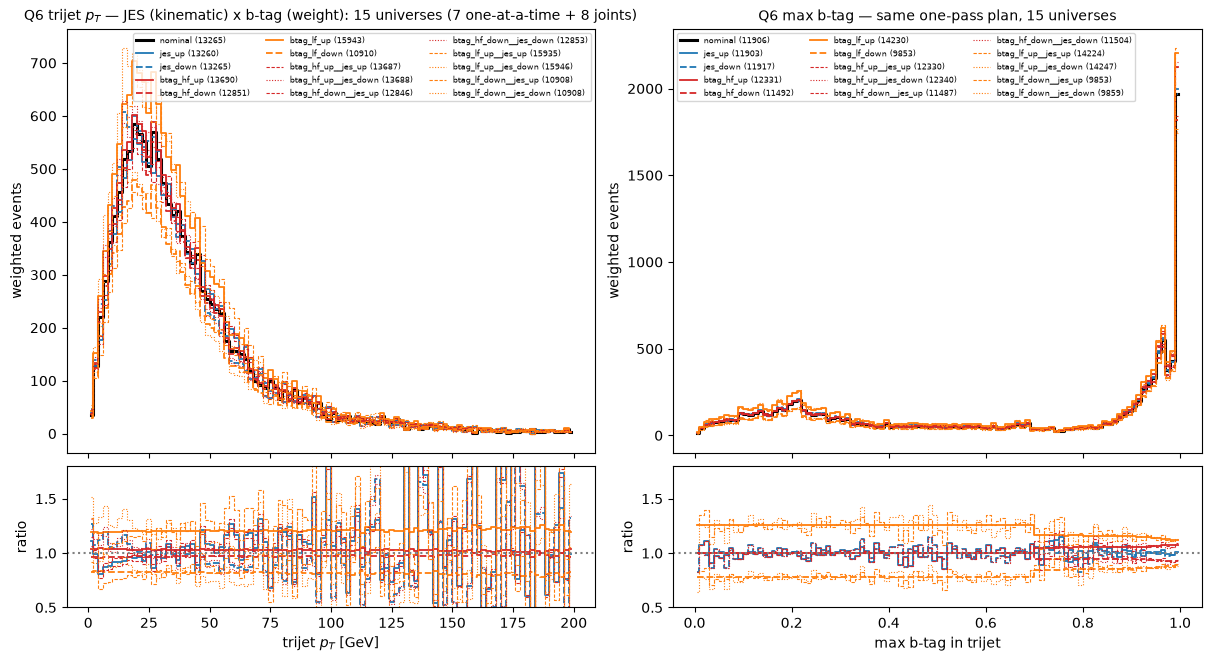

In [22]:
import correctionlib
import graphed
import graphed_histogram as gh
import hist as _hist
import hist.graphed as hg
import numpy as np
from graphed.awkward import gak

import systematics  # two correctionlib sets standing in for the POG JSONs (see the file)

JES_JSON = systematics.jes_correctionset()
BTAG_JSON = systematics.btag_correctionset()
# With args= the positional evaluator is never consulted: the correctionlib plugin evaluates the
# External itself, in-process and on every worker alike, rebuilt from the payload bytes -- one
# evaluation path per backend. The bound methods below only document the correction applied.
jes_eval = correctionlib.CorrectionSet.from_string(JES_JSON.decode())["JES_Total"].evaluate
btag_eval = correctionlib.CorrectionSet.from_string(BTAG_JSON.decode())["deepJet_shape"].evaluate

# ---- 1. JES: a KINEMATIC systematic, from correctionlib, on the jet four-vector ----
# JES_Total.evaluate(eta, pt) -> fractional uncertainty. apply_correction records an External
# carrying (payload, call template, content hash) -- not a lambda -- so it serializes into the
# durable plan and reproduces on another machine.
jes = gak.apply_correction(
    JES_JSON, "JES_Total", [events.Jet.eta, events.Jet.pt], jes_eval, args=["$0", "$1"]
)


def jet_p4(pt, mass):  # a Lorentz vector carrying its jet's b-tag along for the ride
    j = gak.zip(
        {"pt": pt, "eta": events.Jet.eta, "phi": events.Jet.phi, "mass": mass, "btag": events.Jet.btag},
        with_name="PtEtaPhiMLorentzVector",
    )
    return gak.zip({"x": j.x, "y": j.y, "z": j.z, "t": j.t, "btag": j.btag}, with_name="LorentzVector")


# Shift the WHOLE four-vector by (1 +/- delta): this changes which jets enter Q6's trijet.
jets = graphed.vary(
    jet_p4(events.Jet.pt, events.Jet.mass),
    "jes",
    up=jet_p4(events.Jet.pt * (1 + jes), events.Jet.mass * (1 + jes)),
    down=jet_p4(events.Jet.pt * (1 - jes), events.Jet.mass * (1 - jes)),
)

# ---- 2. Q6 proper, over the VARIED jets ----
tri = gak.combinations(jets, 3, fields=["j1", "j2", "j3"])
p4 = tri.j1 + tri.j2 + tri.j3
best = gak.argmin(abs(p4.mass - 172.5), axis=1, keepdims=True)
trijet_pt = p4.pt[best]  # left ragged (per event) so the per-event weight broadcasts at fill
max_btag = np.maximum(tri.j1.btag, np.maximum(tri.j2.btag, tri.j3.btag))[best]
chosen = tri[best]  # the three jets the Q6 selection actually uses -- per universe


# ---- 3. b-tag: a WEIGHT systematic evaluated on the VARIED trijet -> PROPAGATION ----
# deepJet_shape is pT-binned and `chosen` is a Varied container, which apply_correction traverses:
# in each jes universe the SF is re-evaluated on THAT universe's shifted pT. No manual fan-out.
def btag_weight(systematic):
    per_jet = None
    for leg in ("j1", "j2", "j3"):
        js = chosen[leg]
        sf = gak.apply_correction(
            BTAG_JSON,
            "deepJet_shape",
            [
                5 * (js.btag > 0.7),  # PROXY flavour: b if tagged
                np.minimum(abs(js.eta), 2.499),
                np.minimum(np.maximum(js.pt, 20.001), 9999.0),
                np.minimum(np.maximum(js.btag, 0.0), 1.0),
            ],
            btag_eval,
            args=[systematic, "$0", "$1", "$2", "$3"],
        )
        per_jet = sf if per_jet is None else per_jet * sf
    return gak.prod(per_jet, axis=1)


sf = {s: btag_weight(s) for s in ("central", "up_hf", "down_hf", "up_lf", "down_lf")}

# ---- 4. the b-tag family: ONE plain vary -> the full 15-universe grid ----
# Each b-tag SF is computed on the jes-varied jets, so the family depends on the jes axis: graphed
# mints the full 3x5 grid on its own. The 8 joints (btag_*__jes_*) are the factorization cross-terms
# -- each SF at its own (jes, btag) coordinate, no placements and no manual loop. composes_as_union=True
# collapses them to the datacard's 7 one-at-a-time templates.
weight = graphed.vary(
    sf["central"],
    "btag",
    hf_up=sf["up_hf"],
    hf_down=sf["down_hf"],
    lf_up=sf["up_lf"],
    lf_down=sf["down_lf"],
)

print("universes:", graphed.labels(weight))

# ---- 5. ONE plan: both Q6 observables + the propagation witness, every universe, one pass ----
h_pt = (
    hg.Hist.new.Reg(100, 0, 200, name="pt3j", label=r"trijet $p_T$ [GeV]")
    .Double()
    .fill(pt3j=trijet_pt, weight=[weight])
)
h_btag = (
    hg.Hist.new.Reg(100, 0, 1, name="btag", label="max b-tag in trijet")
    .Double()
    .fill(btag=max_btag, weight=[weight])
)
# a 1-bin histogram of a constant: its content IS the sum of the b-tag SF, isolated from the
# observable, so the jes -> pT -> SF propagation is directly readable per universe.
h_sf = hg.Hist.new.Reg(1, -1, 1, name="x").Double().fill(x=gak.num(events.Jet) * 0.0, weight=[weight])

out = gh.unpack(
    EXECUTOR.run(gh.plan({"trijet_pt": h_pt, "max_btag": h_btag, "btag_sf": h_sf}, steps_per_file=8)).value
)

print(f"\n{'universe':<16} {'sum(trijet_pt)':>14} {'sum(max_btag)':>14} {'sum(b-tag SF)':>16}")
for label in graphed.labels(weight):
    pt_sum, btag_sum, sf_sum = (float(out[k][label].sum()) for k in ("trijet_pt", "max_btag", "btag_sf"))
    print(f"{label:<16} {pt_sum:14.6f} {btag_sum:14.6f} {sf_sum:16.6f}")

nom_sf, up_sf = (float(out["btag_sf"][k].sum()) for k in ("nominal", "jes_up"))
print(
    "\npropagation: the b-tag SF is evaluated on the shifted pT, so sum(b-tag SF) MOVES with jes"
    " -- with no loop over universes in the analysis code:"
    f"\n  nominal {nom_sf:.6f} -> jes_up {up_sf:.6f}  ({100 * (up_sf / nom_sf - 1):+.5f}%)"
)

# One-at-a-time styles; each joint inherits its b-tag component's colour and is tinted by the jes
# leg (thin, dashed/dotted), so every cross-term sits beside its one-at-a-time sibling.
BASE = {
    "nominal": ("k", "-", 2.2),
    "jes_up": ("C0", "-", 1.3),
    "jes_down": ("C0", "--", 1.3),
    "btag_hf_up": ("C3", "-", 1.3),
    "btag_hf_down": ("C3", "--", 1.3),
    "btag_lf_up": ("C1", "-", 1.3),
    "btag_lf_down": ("C1", "--", 1.3),
}
JES_LEG = {"jes_up": (0, (3, 1.5)), "jes_down": (0, (1, 1.5))}  # dashed vs dotted for the jes leg
STYLE = dict(BASE)
for _label in graphed.labels(weight):
    if "__" in _label:  # a joint: colour by b-tag component, line style by jes leg
        _btag_leg, _jes_leg = _label.split("__")
        STYLE[_label] = (BASE[_btag_leg][0], JES_LEG[_jes_leg], 0.8)
panels = {
    "trijet_pt": (
        r"trijet $p_T$ [GeV]",
        r"Q6 trijet $p_T$ — JES (kinematic) x b-tag (weight): 15 universes (7 one-at-a-time + 8 joints)",
    ),
    "max_btag": ("max b-tag in trijet", "Q6 max b-tag — same one-pass plan, 15 universes"),
}
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6.5),
    sharex="col",
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)
for col, (name, (xlabel, title)) in enumerate(panels.items()):
    ax, rax = axes[0][col], axes[1][col]
    universes = {label: _hist.Hist(h) for label, h in out[name].items()}
    centers = universes["nominal"].axes[0].centers
    nominal = universes["nominal"].values()
    for label, (color, ls, lw) in STYLE.items():
        vals = universes[label].values()
        ax.step(centers, vals, where="mid", color=color, ls=ls, lw=lw, label=f"{label} ({vals.sum():.0f})")
        if label != "nominal":
            ratio = np.divide(vals, nominal, out=np.full_like(nominal, np.nan), where=nominal > 0)
            rax.step(centers, ratio, where="mid", color=color, ls=ls, lw=lw)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("weighted events")
    ax.legend(fontsize=6, ncol=3)
    rax.axhline(1.0, ls=":", color="gray")
    rax.set_ylabel("ratio")
    rax.set_xlabel(xlabel)
    rax.set_ylim(0.5, 1.8)
plt.show()

## Parallel speedup: measured honestly

Every number here is measured in this notebook's own runs (no figure is asserted from
intuition). Four methodology rules — each one fixed a measured distortion — make the speedup
meaningful, and the executor delivers close to the ideal 4x once they are applied:

1. **Record/compile once, time execution only.** Graph construction is a one-time cost (a real
   analysis compiles once and runs over many partitions); timed inline it caps an 8-query pass
   at ~2.8x by Amdahl's law no matter how good the executor is.
2. **One combined plan, so both runners do identical I/O** (`adl.query_plan(list(adl.QUERIES), files)`:
   all eight queries in one graph, one pass over the data). Per-query plans let pool workers
   reuse file handles *across* plans while the sequential runner re-opens per plan — an
   asymmetry that fakes a large speedup.
3. **Warm what should be warm, then take a median.** Worker imports (~0.75 s, one-time) are
   paid untimed on a *separate* file; the OS page cache is warmed by an untimed sequential pass; and because `open_once` caches files **per worker** while the pool dispatches tasks to
   whichever worker is free, a single timed pass can route files to workers that must re-read
   them cold (~30 ms each). At sub-second totals that jitter dominates, so we warm twice and take **50 timed
   samples** of each component — the violin plot below shows the full distribution rather than
   a single number, and the speedup is quoted from the medians.
4. **One task per file.** This skim stores each branch as a single basket, so splitting a file
   into sub-ranges re-decompresses the whole basket per chunk (measured: sequential time grows
   ~linearly with chunk count). One task per file reads each basket exactly once.

**What the per-task cost actually is (measured, persistent pool):** the framework round-trip —
submit, deliver, return — is **~0.08 ms per task**, i.e. a pickle-and-queue hop, not a process
spawn; the real per-task *work* (open, decompress, assemble the NanoEvents chunk and evaluate all
eight queries) is **~125 ms**. The process callable carrying the compiled IR is delivered to each
worker **once** and cached by content hash, so per-task messages carry only a partition
reference — the IR is not re-shipped per task. Over 50 samples the median lands near the ideal 4x
on 4 workers at both sizes (3.5–4.6x across this notebook's executions); the exact figure varies run to run at this sub-second-per-pass scale
(see the cell output below and the violins' spread — the distributions carry visible tails).

**This run.** The violin plot below compares all three process-executor runs — `ProcessPoolExecutor` (hub-and-spoke), `ProcessPoolExecutor` (full-registry peer), and `PinnedPoolExecutor` (identity-pinned, bounded O(log N) overlay) — each with the **live dashboard (and optionally statistical profiler) attached** (the realistic *actively-debugging* worst case, not a bare pass). All three land near 4x at both sizes: the monitored-run collection path used to drain worker telemetry on a coarse 20 ms poll cadence — a fixed per-run tail that cost ~13% of a sub-second pass — now drains on a 2 ms cadence, so the instrumented speedup tracks the uninstrumented one.

In [23]:
import os
import shutil

import numpy as np
from graphed.core.execution import SequentialRunner
from graphed.debug import Dashboard
from graphed_executors.local import PinnedPoolExecutor, ProcessPoolExecutor

SCALED = "data/_scaled"
os.makedirs(SCALED, exist_ok=True)


def copies(n):
    out = []
    for i in range(n):
        p = os.path.join(SCALED, f"part{i}.root")
        if not os.path.exists(p):
            shutil.copy("data/Run2012B_SingleMu_50k.root", p)
        out.append(p)
    return out


WARMUP = os.path.join(SCALED, "warmup.root")
if not os.path.exists(WARMUP):
    shutil.copy("data/Run2012B_SingleMu_50k.root", WARMUP)

N_SAMPLES = 50
SCALES = [("400k (8 files)", 8), ("1.6M (32 files)", 32)]


def sample_times(run, plan, *, warm=2, n=N_SAMPLES):
    """Warm, then return n execution-time samples (the distribution, not a point estimate)."""
    for _ in range(warm):
        run(plan)
    out = []
    for _ in range(n):
        t0 = time.perf_counter()
        run(plan)
        out.append(time.perf_counter() - t0)
    return np.asarray(out)


# ONE live dashboard on port 8989 (won't clash with Jupyter), profiler off (profile=False). Its
# monitor is attached to every executor run below, so every number here is for a *monitored* run
# -- timeline streaming over the websocket -- not a bare pass. Pass profile=True to add a streamed
# profile and flamegraph, at a small performance cost.
dash = Dashboard(port=8989, profile=False).start()

plans = {label: adl.query_plan(list(adl.QUERIES), copies(n)) for label, n in SCALES}
warm_plan = adl.query_plan(list(adl.QUERIES), [WARMUP])

seq = SequentialRunner()
seq_samples = {label: sample_times(seq.run, plans[label]) for label, _ in SCALES}
samples = {}  # (executor, label) -> parallel execution-time array[N]
for label, _ in SCALES:
    s = seq_samples[label]
    print(f"{label}: SequentialRunner median {np.median(s):.2f}s [{s.min():.2f}-{s.max():.2f}]")

400k (8 files): SequentialRunner median 1.11s [1.00-1.46]
1.6M (32 files): SequentialRunner median 3.94s [3.82-4.17]


In [24]:
# ProcessPoolExecutor -- old hub-and-spoke model, dashboard (+ optional profiler) attached
with ProcessPoolExecutor(max_workers=4, persistent=True, comms=None, monitor=dash.monitor) as pool:
    pool.run(warm_plan)  # pay the worker imports once, untimed, on a separate file
    for label, _ in SCALES:
        samples[("ProcessPoolExecutor (hub)", label)] = sample_times(pool.run, plans[label])
        s = samples[("ProcessPoolExecutor (hub)", label)]
        print(f"ProcessPoolExecutor (hub) {label}: median {np.median(s):.3f}s  "
              f"-> {np.median(seq_samples[label]) / np.median(s):.2f}x over sequential")

ProcessPoolExecutor (hub) 400k (8 files): median 0.250s  -> 4.45x over sequential


ProcessPoolExecutor (hub) 1.6M (32 files): median 0.984s  -> 4.00x over sequential


In [25]:
# ProcessPoolExecutor -- full-registry peer reduction (the default), dashboard (+ optional profiler) attached
with ProcessPoolExecutor(max_workers=4, persistent=True, monitor=dash.monitor) as pool:
    pool.run(warm_plan)  # pay the worker imports once, untimed, on a separate file
    for label, _ in SCALES:
        samples[("ProcessPoolExecutor", label)] = sample_times(pool.run, plans[label])
        s = samples[("ProcessPoolExecutor", label)]
        print(f"ProcessPoolExecutor {label}: median {np.median(s):.3f}s  "
              f"-> {np.median(seq_samples[label]) / np.median(s):.2f}x over sequential")

ProcessPoolExecutor 400k (8 files): median 0.244s  -> 4.56x over sequential


ProcessPoolExecutor 1.6M (32 files): median 0.974s  -> 4.04x over sequential


In [26]:
# PinnedPoolExecutor -- identity-pinned, bounded O(log N) overlay (for large many-core machines),
# same live dashboard (+ optional profiler) attached so it is an apples-to-apples comparison
with PinnedPoolExecutor(max_workers=4, persistent=True, monitor=dash.monitor) as pool:
    pool.run(warm_plan)
    for label, _ in SCALES:
        samples[("PinnedPoolExecutor", label)] = sample_times(pool.run, plans[label])
        s = samples[("PinnedPoolExecutor", label)]
        print(f"PinnedPoolExecutor {label}: median {np.median(s):.3f}s  "
              f"-> {np.median(seq_samples[label]) / np.median(s):.2f}x over sequential")

dash.stop()

PinnedPoolExecutor 400k (8 files): median 0.244s  -> 4.56x over sequential


PinnedPoolExecutor 1.6M (32 files): median 0.970s  -> 4.06x over sequential


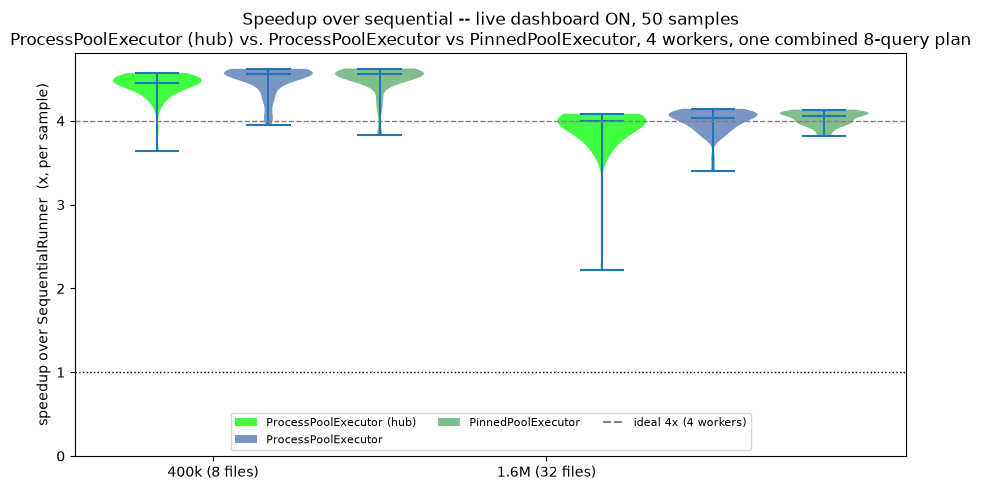

ProcessPoolExecutor (hub) 400k (8 files)   median 4.45x
ProcessPoolExecutor  400k (8 files)   median 4.56x
PinnedPoolExecutor   400k (8 files)   median 4.56x
ProcessPoolExecutor (hub) 1.6M (32 files)  median 4.00x
ProcessPoolExecutor  1.6M (32 files)  median 4.04x
PinnedPoolExecutor   1.6M (32 files)  median 4.06x


In [27]:
from matplotlib.patches import Patch

executors = ["ProcessPoolExecutor (hub)", "ProcessPoolExecutor", "PinnedPoolExecutor"]
colors = {"ProcessPoolExecutor (hub)": "#00FF00", "ProcessPoolExecutor": "#4C72B0", "PinnedPoolExecutor": "#55A868"}
order = [(ex, label) for label, _ in SCALES for ex in executors]  # PP/Pin x 400k, then PP/Pin x 1.6M
positions = [1, 2, 3, 5, 6, 7]
speedups = [np.median(seq_samples[label]) / samples[(ex, label)] for ex, label in order]  # per-sample

fig, ax = plt.subplots(figsize=(9, 5))
parts = ax.violinplot(speedups, positions=positions, showmedians=True, showextrema=True, widths=0.8)
for body, (ex, _label) in zip(parts["bodies"], order):
    body.set_facecolor(colors[ex])
    body.set_alpha(0.75)
ax.axhline(4.0, ls="--", color="gray", lw=1)  # ideal speedup for 4 workers
ax.axhline(1.0, ls=":", color="black", lw=1)  # sequential baseline
ax.set_xticks([1.5, 4.5], [label for label, _ in SCALES])
ax.set_ylabel("speedup over SequentialRunner  (x, per sample)")
ax.set_ylim(bottom=0)
handles = [Patch(facecolor=colors[e], alpha=0.75, label=e) for e in executors]
handles += [plt.Line2D([], [], ls="--", color="gray", label="ideal 4x (4 workers)")]
ax.legend(handles=handles, loc="lower center", ncol=3, fontsize=8)
ax.set_title(f"Speedup over sequential -- live dashboard ON, {N_SAMPLES} samples\n"
             "ProcessPoolExecutor (hub) vs. ProcessPoolExecutor vs PinnedPoolExecutor, 4 workers, one combined 8-query plan")
fig.tight_layout()
plt.show()

for ex, label in order:
    spd = np.median(seq_samples[label]) / np.median(samples[(ex, label)])
    print(f"{ex:<20} {label:<16} median {spd:.2f}x")

### Watching for less: lean events and a connection per worker

The dashboard above receives three events per task, all routed through the driver.
`NetworkMonitor(url, lean=True, per_worker=True)` sends one event per task (the dashboard
derives the start) and lets each worker process open its own connection to the dashboard. The
same 400k pass, with 50 samples:

In [28]:
from graphed.debug import NetworkMonitor

label = SCALES[0][0]
lean = NetworkMonitor(dash.server.ingest_url, lean=True, per_worker=True)
with ProcessPoolExecutor(max_workers=4, persistent=True, monitor=lean) as pool:
    pool.run(warm_plan)
    lean_samples = sample_times(pool.run, plans[label])
lean.close()
base = samples[("ProcessPoolExecutor", label)]
print(
    f"{label}: default events median {np.median(base):.3f}s, lean + per-worker median {np.median(lean_samples):.3f}s"
)

400k (8 files): default events median 0.244s, lean + per-worker median 0.250s


### Recording the next query while this one runs

Recording and compiling a query is driver work, and while `run()` executes the driver only
waits. `submit(plan)` returns a `concurrent.futures.Future` at once, so the driver records query
N+1 while query N runs on the workers; `.result()` is exactly what `run(plan)` returns. Plans
still execute one at a time, in submit order. Below, the eight queries are recorded and run over
eight partitions each, first one after another, then pipelined through `submit`. On a 50k-event
skim a query runs in tens of milliseconds, so these timings are noisy and say little about
throughput on a real dataset.

In [29]:
def one_by_one():
    return {q: EXECUTOR.run(adl.query_plan(q, WHERE, steps_per_file=8)).value for q in adl.QUERIES}


def pipelined():
    futures = {q: EXECUTOR.submit(adl.query_plan(q, WHERE, steps_per_file=8)) for q in adl.QUERIES}
    return {q: f.result().value for q, f in futures.items()}


t_run, t_submit = [], []
for _ in range(10):
    t0 = time.perf_counter()
    a = one_by_one()
    t_run.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    b = pipelined()
    t_submit.append(time.perf_counter() - t0)
same = all(np.array_equal(a[q][k].values(flow=True), b[q][k].values(flow=True)) for q in a for k in a[q])
print(
    f"8 queries, recorded + run: run() median {np.median(t_run):.3f}s, submit() median {np.median(t_submit):.3f}s "
    f"({np.median(t_run) / np.median(t_submit):.2f}x); identical histograms: {same}"
)

8 queries, recorded + run: run() median 0.543s, submit() median 0.413s (1.31x); identical histograms: True


### Partition boundaries that follow the baskets

Rule 4 above: this skim stores each branch in a single basket, so eight partitions of one file
decompress that basket eight times. `uproot.graphed(..., align_baskets=True)` moves each
partition's boundaries, when it is read, to the nearest basket boundary shared by the branches it
reads (a partition left empty reads nothing). `graphed_partitions(..., align_baskets=True)` does
it where the plan is built, so here the file becomes one task. Q6 on the pool, 20 samples each
(the same skim-size caveat applies):

In [30]:
from uproot._graphed import graphed_partitions

aligned = graphed_partitions({WHERE: "Events"}, steps_per_file=8, align_baskets=True)
print(
    "partitions:", len(graphed_partitions({WHERE: "Events"}, steps_per_file=8)), "->", len(aligned), "aligned"
)
variants = {
    "8 steps": adl.query_plan("q6", WHERE, steps_per_file=8),
    "8 steps, align_baskets": adl.query_plan("q6", WHERE, steps_per_file=8, align_baskets=True),
    "aligned partitions": adl.query_plan("q6", WHERE, partitions=aligned),
}
reference = EXECUTOR.run(variants["8 steps"]).value
for label, plan in variants.items():
    t = sample_times(EXECUTOR.run, plan, n=20)
    value = EXECUTOR.run(plan).value
    same = all(np.array_equal(value[k].values(flow=True), reference[k].values(flow=True)) for k in reference)
    print(f"{label:<24} {len(plan.tasks)} task(s)  median {np.median(t) * 1e3:5.1f} ms  identical: {same}")

partitions: 8 -> 1 aligned


8 steps                  8 task(s)  median  65.2 ms  identical: True


8 steps, align_baskets   8 task(s)  median  61.2 ms  identical: True


aligned partitions       1 task(s)  median  45.6 ms  identical: True


### Stopping a run early: pause, resume, cancel

A `RunControl` handed to an executor steers it from any thread: `pause()` starts no new task,
`resume()` carries on, and `cancel()` starts no new task, waits for the ones already running
and returns the sum of the partitions that finished, marked `stopped=StopReason.CANCELLED`. The
dashboard drives the same object from the browser with `Dashboard(control=True)`. Here a small
monitor presses cancel, from another thread, as soon as the first task of the 32-file combined
plan finishes:

In [31]:
import threading

from graphed.core import RunControl, TaskPhase


class CancelAfterFirst:
    """A monitor that presses cancel, from another thread, once the first task finishes."""

    def __init__(self, control):
        self.first = threading.Event()
        threading.Thread(target=lambda: (self.first.wait(), control.cancel()), daemon=True).start()

    def on_task(self, event):
        if event.phase is TaskPhase.FINISHED:
            self.first.set()

    def on_profile(self, worker, payload):
        pass

    def on_combine(self, leaves_done):
        pass

    def worker_profiler_factory(self):
        return None


ctl = RunControl()
label = SCALES[1][0]
with ProcessPoolExecutor(max_workers=4, persistent=True, control=ctl, monitor=CancelAfterFirst(ctl)) as pool:
    res = pool.run(plans[label])
print(
    f"stopped={res.stopped}: {res.n_partitions} of {len(plans[label].tasks)} files folded, "
    f"{res.value['q1'].sum(flow=True):.0f} of {50000 * len(plans[label].tasks)} events in Q1; "
    f"the control is {ctl.state} again"
)

stopped=cancelled: 7 of 32 files folded, 350000 of 1600000 events in Q1; the control is running again


## Debugging: errors point at **your** code — even from remote workers

The classic failure mode of distributed analysis (and dask pain point) is the opaque remote
traceback: a wall of framework internals with your actual mistake nowhere in sight.
`graphed-debug` fixes this twice over:

1. **Record-time**: a field that does not exist fails the moment you write the bad line —
   before any data is read.
2. **Run-time**: a data-dependent failure inside a worker surfaces as a **`StageError`** — a
   real, *picklable* exception carrying the failing op, your analysis frames, the input forms,
   and **which partition** failed — re-raised by the driver still pointing at your line.

In [32]:
# 1) record-time: a typo'd field fails IMMEDIATELY, at the offending line, no data read
try:
    bad = events.Jet.ptt  # <- the typo
except AttributeError as err:
    print(type(err).__name__, "->", err)

AttributeError -> ptt


### A data-dependent bug the typetracer *cannot* see

`debugging.faulty_q4` rebuilds the jagged jets from flattened pt — with the counts **off by
one**. The forms are all consistent at record time, so it records cleanly; only a worker
touching real data trips it:

In [33]:
import debugging

print(inspect.getsource(debugging.faulty_q4))

def faulty_q4(jet_pt: Any) -> Any:
    """A buggy take on q4's jet handling: rebuild the jagged jet pT from its flat values — with
    the counts off by one. Records cleanly; fails on real data."""
    from graphed.awkward import gak

    flat_pt = gak.flatten(jet_pt, axis=1)
    counts = gak.num(jet_pt, axis=1) + 1  # BUG: off-by-one counts
    rebuilt = gak.unflatten(flat_pt, counts, axis=0)  # <-- graphed-debug points HERE
    return gak.sum(rebuilt, axis=1)



In [34]:
# 2) run-time, driver-side first: graphed.debug.run executes and maps the failure
import awkward as ak
import graphed.debug as gd
from graphed import Session
from graphed.awkward import AwkwardBackend, from_awkward

raw = uproot.open(WHERE)["Events"].arrays(["Jet_pt"], entry_stop=2000)
s_dbg = Session(AwkwardBackend())
g_dbg = from_awkward(s_dbg, "events", ak.Array({"Jet_pt": raw.Jet_pt}))
try:
    gd.run(s_dbg, debugging.faulty_q4(g_dbg.Jet_pt), opt_level=1, partition="skim@0:2000")
except gd.StageError as err:
    print(gd.format_traceback(err))

Traceback (most recent call last) — user analysis frames:
      File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_16565/3634459537.py", line 9, in <module>
          from_awkward(s_dbg, 'events', ak.Array({'Jet_pt': raw.Jet_pt}))
      File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_16565/3634459537.py", line 11, in <module>
          g_dbg.Jet_pt
      File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 27, in faulty_q4
          gak.flatten(jet_pt, axis=1)
  --> File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 29, in faulty_q4
          gak.unflatten(flat_pt, counts, axis=0)
ValueError: structure imposed by 'counts' does not fit in the array or partition at axis=0  [stage op 'ak.unflatten', partition skim@0:2000, opt_level=1]
  input forms: ## * float32, ## * int64


### The same failure from a **process pool**, intact

The faulty analysis as a task graph over four real partitions, run on spawned workers. The
`StageError` raised inside a worker **pickles across the process boundary** and re-raises in
the driver — op, cause, your frames, and the failing partition all preserved (never an opaque
string):

In [35]:
from graphed_executors.local import ProcessPoolExecutor

plan = debugging.faulty_plan([WHERE], chunksize=2**14)
try:
    ProcessPoolExecutor(max_workers=2).run(plan)
except gd.StageError as err:
    print("caught in the driver:", type(err).__name__)
    print("  failing op:        ", err.op)
    print("  cause:             ", err.cause_type, "—", err.cause_message[:70])
    print("  failing partition: ", err.partition)
    print("  your code:         ", f"{err.user_frame.filename}:{err.user_frame.lineno}")
    print()
    print(gd.format_traceback(err))

caught in the driver: StageError
  failing op:         ak.unflatten
  cause:              ValueError — structure imposed by 'counts' does not fit in the array or partition a
  failing partition:  data/Run2012B_SingleMu_50k.root@0:16384
  your code:          /Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py:29

Traceback (most recent call last) — user analysis frames:
      File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 46, in run_faulty_chunk
          from_awkward(s, 'events', ak.Array({'Jet_pt': raw.Jet_pt}))
      File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 47, in run_faulty_chunk
          g.Jet_pt
      File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 27, in faulty_q4
          gak.flatten(jet_pt, axis=1)
  --> File "/Users/lgray/vibe-coding/coffea-benchmarks-graphed-mvp/debugging.py", line 29, in faulty_q4
          gak.unflatten(flat_pt, counts, axis=0)
ValueE

### The traceback survives **higher optimization levels**

At `opt_level=0` the graph executes 1:1 — one stage per recorded op (the canonical mode for
pinpointing where a value first goes wrong). At `opt_level>=1`, maximal op runs are **fused**
into multi-member stages — the structure that actually executes. Crucially, every fused member
keeps its own source frame through lowering, so the buggy op can be buried in the middle of a
fused stage and the `StageError` still lands on the same line of *your* code:

In [36]:
lowered0 = gd.lower(s_dbg, debugging.faulty_q4(g_dbg.Jet_pt), opt_level=0)
lowered1 = gd.lower(s_dbg, debugging.faulty_q4(g_dbg.Jet_pt), opt_level=1)
print(
    f"opt_level=0: {len(lowered0.stages)} stages, members per stage = "
    f"{[len(st.members) for st in lowered0.stages]}  (1:1, one op per stage)"
)
print(
    f"opt_level=1: {len(lowered1.stages)} stages, members per stage = "
    f"{[len(st.members) for st in lowered1.stages]}  (fused)"
)
fused = next(st for st in lowered1.stages if any(m.op == "ak.unflatten" for m in st.members))
print()
print("the fused stage holding the bug — every member keeps its own source frame:")
for m in fused.members:
    marker = "  <-- the bug" if m.op == "ak.unflatten" else ""
    print(f"  {m.op:16s} {m.provenance.filename.split('/')[-1]}:{m.provenance.lineno}{marker}")

opt_level=0: 7 stages, members per stage = [1, 1, 1, 1, 1, 1, 1]  (1:1, one op per stage)
opt_level=1: 4 stages, members per stage = [1, 1, 4, 1]  (fused)

the fused stage holding the bug — every member keeps its own source frame:
  ak.flatten       debugging.py:27
  ak.num           debugging.py:28
  add              debugging.py:28
  ak.unflatten     debugging.py:29  <-- the bug


In [37]:
for lvl in (0, 1):
    try:
        gd.run(s_dbg, debugging.faulty_q4(g_dbg.Jet_pt), opt_level=lvl, partition=f"opt_level={lvl}")
    except gd.StageError as err:
        print(
            f"opt_level={err.opt_level}: {err.op} fails at "
            f"{err.user_frame.filename.split('/')[-1]}:{err.user_frame.lineno} "
            f"({err.cause_type})"
        )
print()
print("same op, same file, same line — fusion never costs you the traceback")

opt_level=0: ak.unflatten fails at debugging.py:29 (ValueError)
opt_level=1: ak.unflatten fails at debugging.py:29 (ValueError)

same op, same file, same line — fusion never costs you the traceback


### Replaying one task, operation by operation

The traceback says where; to see what each step produced, replay the task on your machine.
`graphed.debug.replay(plan, key, *outputs)` re-executes task `key` of an `aggregate_plan` plan at
`opt_level=0` on that task's input: `.steps()` yields each operation lazily, with its value and
the time it took, and a failing step raises the run's own `StageError` at your line. `.value` is
the task's partial, and `.diff()` compares it with the run's (for a task that failed, it
re-raises the `StageError`). `aggregate_plan(..., store=<directory or URL>)` keeps every task's
exact input for replay; reading NanoEvents (or any uproot source) that capture does not work yet, so here replay
re-reads the partition.

In [38]:
from graphed import aggregate_plan
from graphed.core.execution import SequentialRunner


def plan_for(output):
    return aggregate_plan(
        output,
        reduce=lambda outs: float(np.sum(outs[0])),
        combine=lambda a, b: a + b,
        empty=lambda: 0.0,
        steps_per_file=4,
    )


def at(frame):
    return f"{frame.filename.rsplit('/', 1)[-1]}:{frame.lineno}"


bad = debugging.faulty_q4(events.Jet.pt)
bad_plan = plan_for(bad)
try:
    SequentialRunner().run(bad_plan)
except gd.StageError as err:
    print("the run failed at", err.op)

replayed = gd.replay(bad_plan, 0, bad)
print("input:", replayed.input_source)
try:
    for step in replayed.steps():
        print(f"  {step.node.op:<13} {step.seconds * 1e3:6.2f} ms  {at(step.node.provenance)}")
except gd.StageError as err:
    print(f"  {err.op:<13} raised {err.cause_type} at {at(err.user_frame)}")

ht = gak.sum(events.Jet.pt[events.Jet.pt > 40.0], axis=None)  # a healthy output
good_plan = plan_for(ht)
total = SequentialRunner().run(good_plan).value
d = gd.replay(good_plan, 2, ht).diff()
print(
    f"healthy task 2: replayed {d.replayed:.1f} GeV, {d.reference} {d.recorded:.1f} GeV, equal={d.equal} "
    f"(run total {total:.1f} GeV)"
)

the run failed at ak.unflatten
input: re-read
  Events          0.00 ms  adl_graphed.py:35
  field           0.06 ms  2966986889.py:6
  field           0.03 ms  2966986889.py:6
  ak.flatten      0.08 ms  debugging.py:27
  ak.num          0.08 ms  debugging.py:28
  add             0.36 ms  debugging.py:28
  ak.unflatten  raised ValueError at debugging.py:29
healthy task 2: replayed 394102.7 GeV, re-evaluated 394102.7 GeV, equal=True (run total 1527687.4 GeV)


## Checkpointing: crash-safe aggregation with a content-addressed store

A query is also a **`DurablePlan`** — the compiled IR plus import-ref'd process/combine/empty callables —
that `graphed-checkpoint` runs through a content-addressed `Store`: every partition's partial is
committed as it completes, a crashed run **resumes from the committed partials alone**, and a
finished store re-runs with everything skipped.

> The cell picks a small `chunksize` so the bundled 50k-event sample tiles into several
> partitions and the simulated crash lands mid-run; on a larger local file, raise it.


In [39]:
import shutil

from graphed.checkpoint import Store, run_resumable
from graphed.checkpoint.runner import _SimulatedInterrupt

import preservation

# 2**13 tiles the bundled 50k-event skim into ~7 partitions, so the kill-after-3 below lands
# mid-run. Running locally on a larger file? Raise chunksize, keeping it small enough that the
# file still tiles into more than 3 partitions (else the simulated crash can never fire).
plan = preservation.durable_q1_plan([WHERE], chunksize=2**13)
store_dir = "data/_checkpoints"
shutil.rmtree(store_dir, ignore_errors=True)
store = Store(store_dir)

# simulate a crash after 3 partitions have been committed
try:
    run_resumable(plan, store, _kill_after=3)
except _SimulatedInterrupt:
    print(f"crashed mid-run; {len(store.completed())} partials survived in the store")

resumed = run_resumable(plan, store)  # SAME store: only the remainder executes
print(f"resumed: skipped={resumed.report.skipped} executed={resumed.report.executed} "
      f"(did_less_work={resumed.report.did_less_work})")

done = run_resumable(plan, store)  # a finished store: nothing left to do
print(f"re-run:  skipped={done.report.skipped} executed={done.report.executed}")
print("total entries in the q1 histogram:", int(sum(done.value)))

crashed mid-run; 3 partials survived in the store
resumed: skipped=3 executed=4 (did_less_work=True)
re-run:  skipped=7 executed=0
total entries in the q1 histogram: 49994


### The same resume, with the store at a URL

Workers on different machines need one store they can all reach. `FsspecStore(url)` runs the
same crash and resume against any fsspec filesystem (`s3://`, `root://`, `file://`, or the
in-memory one used here), and a new store object given only the URL finds the committed
partials. It needs `pip install "graphed[checkpoint]"` plus the URL's own fsspec driver.

In [40]:
from graphed.checkpoint import FsspecStore

URL = "memory://adl-checkpoints"
try:
    run_resumable(plan, FsspecStore(URL), _kill_after=3)
except _SimulatedInterrupt:
    print(f"crashed mid-run; {len(FsspecStore(URL).completed())} partials survived at {URL}")

resumed = run_resumable(plan, FsspecStore(URL))
print(
    f"resumed: skipped={resumed.report.skipped} executed={resumed.report.executed}; "
    f"same histogram as the local store: {np.array_equal(resumed.value, done.value)}"
)

crashed mid-run; 3 partials survived at memory://adl-checkpoints
resumed: skipped=3 executed=4; same histogram as the local store: True


## Analysis preservation: a self-contained, reproducible bundle

`graphed-preserve` captures the analysis — the canonical IR, its datasets (content-addressed),
and **the histogram itself as part of the payload**: since the fill is an External IR node whose
identity is the SHA-256 of its canonical axes/storage spec, that spec IS its content-addressed
payload, synthesized at build time from the node's own params. The preserved IR **ends at the
fill** (no separate histogram spec), `inspect()` renders it without executing anything, and
`reproduce()` returns the histogram itself, bit for bit.

In [41]:
from graphed.preserve import inspect as inspect_bundle, reproduce
import preservation
import shutil

shutil.rmtree("data/_bundle", ignore_errors=True)
bundle, build_reference = preservation.preserve_q5("data/_bundle", "data/Run2012B_SingleMu_50k.root")

# the histogram is IN the payload inventory: the fill's canonical spec, content-addressed
entry = next(e for e in bundle.manifest["externals"] if e["kind"] == "histogram")
print("preserved histogram payload:", entry["kind"], entry["content_hash"][:23] + "...")
print("separate histogram spec in the manifest:", bundle.manifest["analysis"]["histogram"])
print()
print(inspect_bundle(bundle))

preserved histogram payload: histogram sha256:2b9194e874cbd423...
separate histogram spec in the manifest: None

Preservation Bundle  fingerprint=sha256:1f264db261af575c4ce3b892458f926f43a1076a6327b7fae278a7e5234b2dd7
  environment: python 3.12.10; 6 pinned packages
  config: {}   seed: 0
  histogram: None
  graph (IR, opt_level=0):
    n0   source    events         params={} <- []   [preservation.py:114]
    n1   op        field          params={'field': 'Muon'} <- [0]   [preservation.py:115]
    n2   op        ak.combinations params={'fields': 'mu1,mu2', 'n': 2} <- [1]   [preservation.py:116]
    n3   op        field          params={'field': 'mu1'} <- [2]   [preservation.py:117]
    n4   op        field          params={'field': 'mu2'} <- [2]   [preservation.py:117]
    n5   op        field          params={'field': 'pt'} <- [3]   [preservation.py:73]
    n6   op        field          params={'field': 'phi'} <- [3]   [preservation.py:73]
    n7   op        cos            params={} <

reproduce() == build-time reference, bit for bit: True


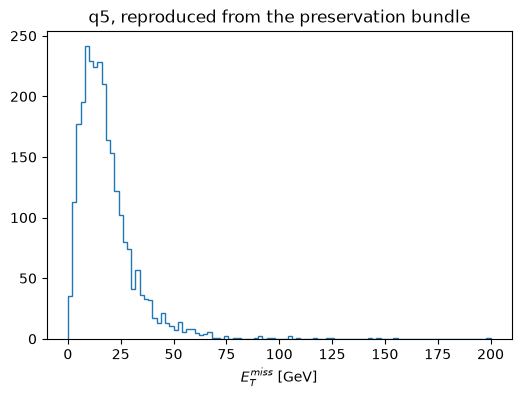

In [42]:
import numpy as np

reproduced = reproduce(bundle)  # the HISTOGRAM itself comes back (a boost_histogram.Histogram)
print("reproduce() == build-time reference, bit for bit:",
      np.array_equal(reproduced.values(flow=True), build_reference.values(flow=True)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.stairs(reproduced.values(), np.linspace(0, 200, 101))
ax.set_xlabel(r"$E_T^{miss}$ [GeV]")
ax.set_title("q5, reproduced from the preservation bundle")
plt.show()

### Re-running the preserved analysis: **optimize → re-target → parallelize**

The bundle deliberately preserves the IR at **opt_level=0** — one node per user operation,
auditable, no fusion — *including the histogram fill as its terminal External node*. A re-run
**reduces it first** (DCE + CSE + equality-saturation stage fusion): the node table below shows
the user's ops collapsing into a few fused stages feeding the fill — this optimized graph is
what actually executes, and each worker's evaluation of it yields a filled histogram directly.

In [43]:
import graphed.core

ir_reduced, stats = preservation.optimized_ir(bundle)
print(f"preserved (opt_level=0): {stats['preserved_nodes']} nodes, kinds={stats['preserved_kinds']}")
print(f"reduced  (executed):     {stats['reduced_nodes']} nodes, kinds={stats['reduced_kinds']}")
print(f"the user's ops now live INSIDE stages: members per stage = {stats['stage_members']}")
print()
print("the OPTIMIZED graph that runs:")
for n in graphed.core.GraphStore.deserialize(ir_reduced).nodes():
    print(f"  node {n['id']}: {n['kind']:9s} inputs={n['inputs']}"
          + (f"  [{n['n_members']} fused user ops]" if n['kind'] == 'stage' else ""))

preserved (opt_level=0): 61 nodes, kinds=['external', 'op', 'source']
reduced  (executed):     13 nodes, kinds=['external', 'source', 'stage']
the user's ops now live INSIDE stages: members per stage = [2, 1, 1, 1, 1, 1, 1, 1, 1, 39, 10]

the OPTIMIZED graph that runs:
  node 0: source    inputs=[]
  node 1: stage     inputs=[0]  [2 fused user ops]
  node 2: stage     inputs=[1]  [1 fused user ops]
  node 3: stage     inputs=[1]  [1 fused user ops]
  node 4: stage     inputs=[2]  [1 fused user ops]
  node 5: stage     inputs=[2]  [1 fused user ops]
  node 6: stage     inputs=[3]  [1 fused user ops]
  node 7: stage     inputs=[3]  [1 fused user ops]
  node 8: stage     inputs=[2]  [1 fused user ops]
  node 9: stage     inputs=[3]  [1 fused user ops]
  node 10: stage     inputs=[5, 4, 7, 6, 8, 9, 2, 3]  [39 fused user ops]
  node 11: stage     inputs=[2, 3, 10, 0]  [10 fused user ops]
  node 12: external  inputs=[11]


And the preserved analysis is not tied to its original dataset: point it at a **new
input file** (here, a copy of the skim under a different name) and run the optimized graph
partition by partition **through the process pool** — the workers evaluate the REDUCED IR.

input file:        data/_retarget_input.root (a renamed copy)
re-targeted + parallel rerun == reproduce(bundle), bit for bit: True


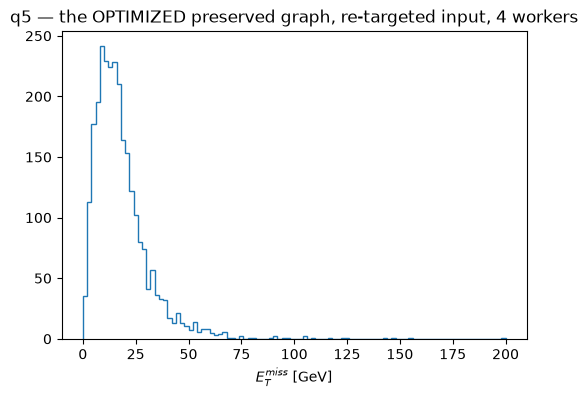

In [44]:
# REDIRECT THE INPUTS: a copy of the skim under a new name stands in for "new data"
shutil.copy("data/Run2012B_SingleMu_50k.root", "data/_retarget_input.root")

rerun, _stats = preservation.rerun_preserved(
    bundle,
    ["data/_retarget_input.root"],
    executor=EXECUTOR,  # the 4-worker pool
)

# VERIFY THE OUTPUTS: the re-targeted parallel run of the OPTIMIZED preserved graph (its
# terminal is the histogram fill) agrees with reproduce() on the original bundle exactly
print("input file:        data/_retarget_input.root (a renamed copy)")
print(
    "re-targeted + parallel rerun == reproduce(bundle), bit for bit:",
    np.array_equal(rerun.values(flow=True), reproduced.values(flow=True)),
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stairs(rerun.values(), np.linspace(0, 200, 101))
ax.set_xlabel(r"$E_T^{miss}$ [GeV]")
ax.set_title("q5 — the OPTIMIZED preserved graph, re-targeted input, 4 workers")
plt.show()

### Keeping a record of how it ran

The bundle says what the analysis is; a run report says what one run of it did: the outcome,
per task its partition, worker, state and duration, the `StageError` if it failed, and the
environment digest. `RunRecorder` is a monitor that records the run, `attach_run_report` keeps
the report inside the bundle without changing its fingerprint (timings differ on every run, the
analysis does not), and `inspect()` shows it without executing anything.

In [45]:
from graphed.debug import RunRecorder
from graphed.preserve import Bundle, attach_run_report

before = bundle.fingerprint()
rec = RunRecorder()
rerun_plan, _ = preservation.retarget_plan(bundle, ["data/_retarget_input.root"])
with ProcessPoolExecutor(max_workers=4, monitor=rec) as pool:
    result = pool.run(rerun_plan)
attach_run_report(bundle, rec.report(result=result).to_json())

reopened = Bundle.open("data/_bundle")
print("fingerprint unchanged:", reopened.fingerprint() == before)
text = inspect_bundle(reopened)
print(text[text.index("run reports:") :])

fingerprint unchanged: True
run reports:
    1a9cd5827dc3 outcome=completed tasks=7 finished=7 errored=0 wall=0.383779s env=same
      environment_digest=sha256:bf3af7a3d84d3c9690a38ea678ff42776ede128c8a71d57058dc9744d6adeee4
      task 0 partition=data/_retarget_input.root:/Events;1:0-8192 worker=w0 state=finished duration=0.048159s
      task 1 partition=data/_retarget_input.root:/Events;1:8192-16384 worker=w1 state=finished duration=0.049185s
      task 2 partition=data/_retarget_input.root:/Events;1:16384-24576 worker=w1 state=finished duration=0.022049s
      task 3 partition=data/_retarget_input.root:/Events;1:24576-32768 worker=w2 state=finished duration=0.048252s
      task 4 partition=data/_retarget_input.root:/Events;1:32768-40960 worker=w2 state=finished duration=0.022508s
      task 5 partition=data/_retarget_input.root:/Events;1:40960-49152 worker=w3 state=finished duration=0.047984s
      task 6 partition=data/_retarget_input.root:/Events;1:49152-50000 worker=w3 state=fin

In [46]:
# release the persistent workers
EXECUTOR.close()
shutil.rmtree(SCALED, ignore_errors=True)
shutil.rmtree("data/_checkpoints", ignore_errors=True)
shutil.rmtree("data/_bundle", ignore_errors=True)
import os
if os.path.exists("data/_retarget_input.root"):
    os.remove("data/_retarget_input.root")